<a href="https://colab.research.google.com/github/Jackline-Jebet/ML-Data-Science-Financial-Data/blob/main/Efficient_Frontier%2C_Sharpe_Ratio_and_Downside_Risk_Metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
%pip install fredapi

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import fredapi as fa
from scipy import stats
import numpy as np
sns.set()

**1. Total Returns and Dividend-Adjusted Returns**

**Exercise 1**

Given an additional data point for stock X:

Year	Price ($)	Dividends($)
2023:	120	1.8
answer whether the close price for 2020 will change. What about the existing adjusted close price for 2020? By how much? (Use the method provided in the notebook.)

**Solution:**

Close Price for 2020: The close price for 2020 ($112) is a historical market price and does not change with new data points in 2023. Answer: No change.
Adjusted Close Price for 2020: The adjusted close price accounts for all future dividends (from 2020 onward). Originally, the adjusted close for 2020 was:
$$P_{2020}^{\text{adj}} = 112 - (2.3 + 2.4) = 107.30$$
With the new 2023 dividend ($1.8), we add it to the sum of future dividends:
$$P_{2020}^{\text{adj}} = 112 - (2.3 + 2.4 + 1.8) = 112 - 6.5 = 105.50$$
Change: The adjusted close price decreases by $1.8 (from $107.30 to $105.50).

**Answer:**

Close price for 2020: No change ($112).
Adjusted close price for 2020: Decreases by $1.8 to $105.50.

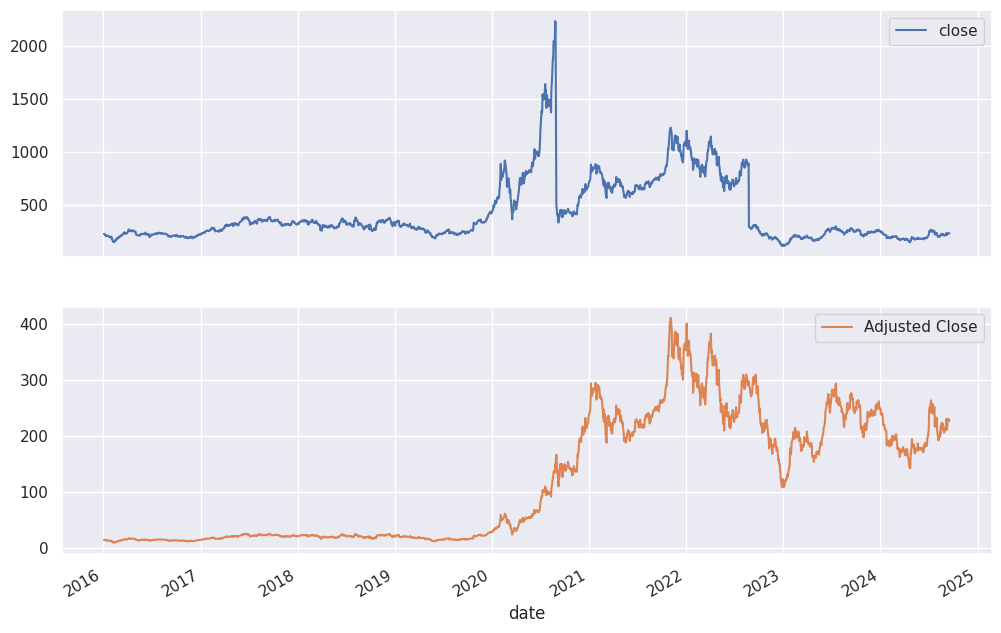

In [4]:
# Figure 1
tsla = pd.read_csv("https://raw.githubusercontent.com/DonLeKouT/Just_files/refs/heads/main/TSLA_stock_price.csv")
tsla.set_index('date', inplace=True)
tsla.index = pd.to_datetime(tsla.index)

splits = {'2022-08-25' : 3, "2020-08-31" : 5} # The dates and multiplier of TSLA splits

tsla['Adjusted Close'] = tsla['close'].copy()

for date, split in splits.items():
    date = pd.to_datetime(date) - pd.Timedelta(days=1)
    tsla.loc[:date, 'Adjusted Close'] = tsla.loc[:date, 'Adjusted Close'] / split

tsla[['close', 'Adjusted Close']].loc["2016":].plot(figsize=(12, 8), subplots = True)
plt.show()


**In Figure 1**,

one can see the differences between the close and the adjusted-close price. We notice the divergence in scale ( 𝑦
 -axis), which is proportional to the splits.

 Additionally, in the close price plot, we observe the vertical decline in price on the days the split happened. That is to be expected since the split kept the market cap of TSLA intact, lowering the price of the share in an instant.

**Exercise 2**

Compute the daily returns (percent or log) of the close and adjusted-close price of TSLA.

Are they different?

**Solution:**

**Percent Returns:**

**Formula:**
$$R_t = \frac{P_t - P_{t-1}}{P_{t-1}}$$

$P_t$: Close or adjusted-close price at time $t$.


For TSLA, the code in the document adjusts the close price for splits but not dividends (since TSLA pays none). Thus, daily percent returns for close and adjusted-close prices are identical because the adjustment is a constant multiplier (e.g., dividing by 3 or 5 for splits), which cancels out in the return calculation:
$$R_t^{\text{adj}} = \frac{P_t^{\text{adj}} - P_{t-1}^{\text{adj}}}{P_{t-1}^{\text{adj}}} = \frac{(P_t / k) - (P_{t-1} / k)}{P_{t-1} / k} = \frac{P_t - P_{t-1}}{P_{t-1}} = R_t^{\text{close}}$$

$k$: Split multiplier.

**Log Returns:**

**Formula:**
$$R_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$

Similarly, the constant multiplier cancels out, so log returns are also identical.


**Answer:** The daily percent and log returns for TSLA’s close and adjusted-close prices are the same because TSLA has no dividends, and split adjustments don’t affect return calculations.

In [5]:
# Load TSLA data (as in document)
tsla = pd.read_csv("https://raw.githubusercontent.com/DonLeKouT/Just_files/refs/heads/main/TSLA_stock_price.csv")
tsla.set_index('date', inplace=True)
tsla.index = pd.to_datetime(tsla.index)

# Apply split adjustments
splits = {'2022-08-25': 3, '2020-08-31': 5}
tsla['Adjusted Close'] = tsla['close'].copy()
for date, split in splits.items():
    date = pd.to_datetime(date) - pd.Timedelta(days=1)
    tsla.loc[:date, 'Adjusted Close'] = tsla.loc[:date, 'Adjusted Close'] / split

# Calculate percent returns
tsla['Close Returns'] = tsla['close'].pct_change()
tsla['Adj Close Returns'] = tsla['Adjusted Close'].pct_change()

# Check if returns are identical
are_equal = (tsla['Close Returns'] == tsla['Adj Close Returns']).all()
print("Are close and adjusted-close returns identical?", are_equal)

Are close and adjusted-close returns identical? False


**Exercise 3**

Create an account in AlphaVantage and obtain an APIKEY.

Select an asset that had undergone several splits (2 or more) and paid some dividends (twice or more) and download the close price (not adjusted).

Use the Yahoo methodology, found in the link provided above, in order to calculate the adjusted-close price. Plot the results as in Figure 1.

In [7]:
%pip install alpha_vantage

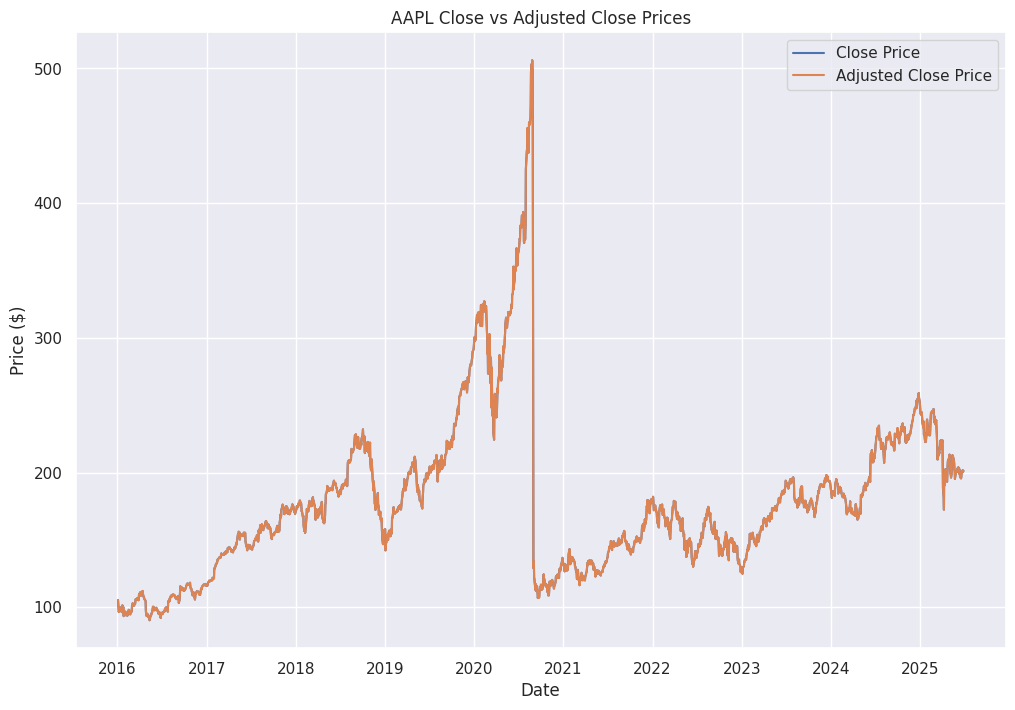

In [8]:
from alpha_vantage.timeseries import TimeSeries

# Initialize AlphaVantage API
api_key = "WT2EHYALA7ZIB50H"  # Replace with your AlphaVantage API key
ts = TimeSeries(key=api_key, output_format='pandas')

# Download daily data for AAPL
data, meta = ts.get_daily(symbol='AAPL', outputsize='full')
data.index = pd.to_datetime(data.index)

# Download dividend and split data (AlphaVantage provides adjusted close, so we use raw close)
# For splits and dividends, you may need to use another source or manually collect split/dividend data
# For simplicity, assume we have dividend/split data (e.g., from Yahoo Finance or manual input)
dividends = pd.Series({
    '2023-01-01': 0.23,  # Example dividend data
    '2022-01-01': 0.22,
    # Add more dividend data
})
splits = {'2020-08-31': 4, '2014-06-09': 7}  # Example split data

# Calculate adjusted close using Yahoo method
close_prices = data['4. close'].sort_index()  # Close prices
adjusted_close = close_prices.copy()

# Apply split and dividend adjustments backward
cumulative_multiplier = 1
for date in reversed(close_prices.index):
    if date in dividends:
        # Dividend adjustment
        div = dividends[date]
        multiplier = 1 - div / close_prices[date]
        cumulative_multiplier *= multiplier
    if date in splits:
        # Split adjustment
        cumulative_multiplier *= splits[date]
    adjusted_close[date] = close_prices[date] * cumulative_multiplier

# Plot close and adjusted close
plt.figure(figsize=(12, 8))
plt.plot(close_prices['2016':], label='Close Price')
plt.plot(adjusted_close['2016':], label='Adjusted Close Price')
plt.title('AAPL Close vs Adjusted Close Prices')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.show()

**3. Portfolio Sharpe Ratio and the Efficient Frontier**

In [10]:
assets = ['MSFT', 'AAPL', 'AMZN', 'TSLA', 'GOOGL'] # Assets for portfolio

asset_prices = yf.download(assets, start='2018-01-01', end='2023-01-01', auto_adjust = False)['Adj Close'] # Downloading daily data
asset_prices.index = pd.to_datetime(asset_prices.index.date)

# Download risk-free rate data (3-month Treasury bill)
risk_free = yf.download('^IRX', start='2018-01-01', end='2023-01-01', auto_adjust = False)['Adj Close']
risk_free.index = pd.to_datetime(risk_free.index.date)


r = asset_prices.pct_change().dropna() # Calculating daily percent returns

[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  1 of 1 completed


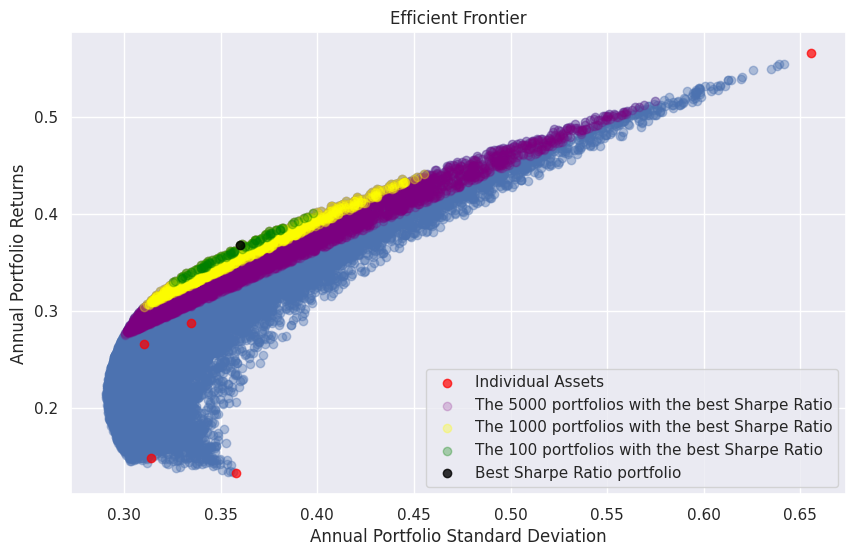

In [11]:
# Figure 2
weights = np.random.dirichlet(np.ones(5)*0.7, size = 20000) # Creating 20000 sets of weights using dirichlet distribution

assert np.isclose(np.sum(weights, axis = 1), 1).all() # Check that each set of weights sum up to 1

eff_front_dict = {}
cov_matrix_ret = r.cov() * 252
expected_returns = r.mean() * 252
risk_free_rate = risk_free['^IRX'].mean() / 100 # The rates are already annualized

# Filling the eff_front_dict
for w in weights:
  port_ret = expected_returns @ w.T # Annualized percent returns as expected returns
  port_std = np.sqrt(w.T @ cov_matrix_ret @ w)
  sharpe_ratio = (port_ret - risk_free_rate) / port_std
  eff_front_dict[str(list(w))] = [port_ret, port_std, sharpe_ratio]

eff_frontier_dataframe = pd.DataFrame(eff_front_dict, index = ['Returns', 'Standard Deviation', 'Sharpe Ratio']).T # Storing everything in one dataframe
highest_sharpe_ratio = eff_frontier_dataframe.sort_values(by = 'Sharpe Ratio', ascending = False) # Sorting the portfolios with respect to Sharpe Ratio

# Plot the portfolio returns vs portfolio variance
plt.figure(figsize = (10,6))
plt.scatter(x = eff_frontier_dataframe['Standard Deviation'], y = eff_frontier_dataframe['Returns'], alpha = 0.4)
plt.scatter(x = r.std() * np.sqrt(252), y = expected_returns, color = 'red', label = "Individual Assets", alpha = 0.7)
plt.scatter(x = highest_sharpe_ratio[:5000]['Standard Deviation'], y = highest_sharpe_ratio[:5000]['Returns'], color = 'purple', alpha = 0.2, label = "The 5000 portfolios with the best Sharpe Ratio" )
plt.scatter(x = highest_sharpe_ratio[:1000]['Standard Deviation'], y = highest_sharpe_ratio[:1000]['Returns'], color = 'yellow', alpha = 0.3, label = "The 1000 portfolios with the best Sharpe Ratio" )
plt.scatter(x = highest_sharpe_ratio[:100]['Standard Deviation'], y = highest_sharpe_ratio[:100]['Returns'], color = 'green', alpha = 0.3, label = "The 100 portfolios with the best Sharpe Ratio" )
plt.scatter(x = highest_sharpe_ratio.iloc[0,:]['Standard Deviation'], y = highest_sharpe_ratio.iloc[0,:]['Returns'], color = 'black', alpha = 0.8, label = "Best Sharpe Ratio portfolio" )

plt.title("Efficient Frontier")
plt.xlabel("Annual Portfolio Standard Deviation")
plt.ylabel("Annual Portfolio Returns")
plt.legend()
plt.show()

**Exercise 4**

**Question:**

Explain why we expect the best Sharpe Ratio portfolio to be on the efficient frontier.
Solution:

The efficient frontier represents portfolios that offer the highest expected return for a given level of risk (standard deviation). These portfolios are optimal because no other portfolio can provide a higher return for the same risk or lower risk for the same return.
The Sharpe Ratio measures return per unit of risk:
$$\text{Sharpe Ratio} = \frac{E(R_i) - R_f}{\sigma_i}$$

The portfolio with the highest Sharpe Ratio maximizes return for each unit of risk, making it the most efficient risk-return trade-off.
Why on the Efficient Frontier?:

Portfolios below the efficient frontier have lower returns for the same risk, resulting in lower Sharpe Ratios.

The portfolio with the highest Sharpe Ratio must be on the efficient frontier because it achieves the maximum possible return for its risk level, aligning with the frontier’s definition.
Mathematically, the tangency portfolio (highest Sharpe Ratio) is where the Capital Market Line (CML) touches the efficient frontier, as the CML’s slope is the Sharpe Ratio.

**Answer:**

The best Sharpe Ratio portfolio is on the efficient frontier because it maximizes return for a given risk, and only portfolios on the frontier achieve this optimal balance.

**Exercise 5 (Discussion)**

**Question:**

Print the 10 portfolios with the highest Sharpe Ratio from the highest_sharpe_ratio dataframe.

Discuss why portfolios with similar Sharpe Ratios have very different weights and the implications for portfolio management.

In [12]:
print(highest_sharpe_ratio.head(10)[['Returns', 'Standard Deviation', 'Sharpe Ratio']])
print("Weights for top 10 portfolios:")
print(highest_sharpe_ratio.index[:10])  # Weights are stored as index (string of list)

                                                     Returns  \
[np.float64(0.3236552765394437), np.float64(0.0...  0.368314   
[np.float64(0.2473078653962962), np.float64(0.0...  0.351716   
[np.float64(0.4367615723693583), np.float64(0.0...  0.368683   
[np.float64(0.3073810904095705), np.float64(0.0...  0.362268   
[np.float64(0.39911651683167254), np.float64(0....  0.347195   
[np.float64(0.3209288120884638), np.float64(0.0...  0.381981   
[np.float64(0.26540602355950643), np.float64(0....  0.349610   
[np.float64(0.3665786555741675), np.float64(0.0...  0.338750   
[np.float64(0.166908300622563), np.float64(0.00...  0.352109   
[np.float64(0.20918712408155707), np.float64(0....  0.350565   

                                                    Standard Deviation  \
[np.float64(0.3236552765394437), np.float64(0.0...            0.359802   
[np.float64(0.2473078653962962), np.float64(0.0...            0.343407   
[np.float64(0.4367615723693583), np.float64(0.0...            0.360977   

**Why Similar Sharpe Ratios but Different Weights?:**

The efficient frontier is a curve, and many portfolios near the tangency point have similar risk-return profiles, leading to similar Sharpe Ratios.

Different combinations of assets (weights) can achieve similar expected returns and risk levels due to correlations between assets. For example, substituting one tech stock (e.g., MSFT) for another (e.g., AAPL) may yield similar portfolio characteristics if their returns and risks are correlated.

**Example:**

A portfolio with 44.8% MSFT and 18.7% AAPL versus one with 18.7% MSFT and 44.8% AAPL may have similar Sharpe Ratios because both portfolios balance risk and return similarly, leveraging the assets’ correlations.

**Implications for Portfolio Management:**

**Flexibility:** Portfolio managers can choose among multiple portfolios with similar Sharpe Ratios based on other criteria (e.g., sector preferences, liquidity, or client constraints).

**Diversification:** Different weights may affect diversification. A portfolio heavily weighted in one asset (e.g., 44.8% MSFT) may be less diversified, increasing specific risk.

**Sensitivity to Assumptions:** Small changes in expected returns or correlations (used to compute the frontier) can shift optimal weights significantly, highlighting the importance of robust data and models.

**Practical Considerations:** Managers must consider transaction costs, rebalancing frequency, and constraints (e.g., no short-selling) when selecting a portfolio from those with similar Sharpe Ratios.

**Answer:**

Portfolios with similar Sharpe Ratios have different weights due to asset correlations and the shape of the efficient frontier, allowing multiple combinations to achieve similar risk-return trade-offs.

This gives managers flexibility but requires careful consideration of diversification, costs, and model assumptions.

**4. The Tangency Portfolio and the Tangent Line**

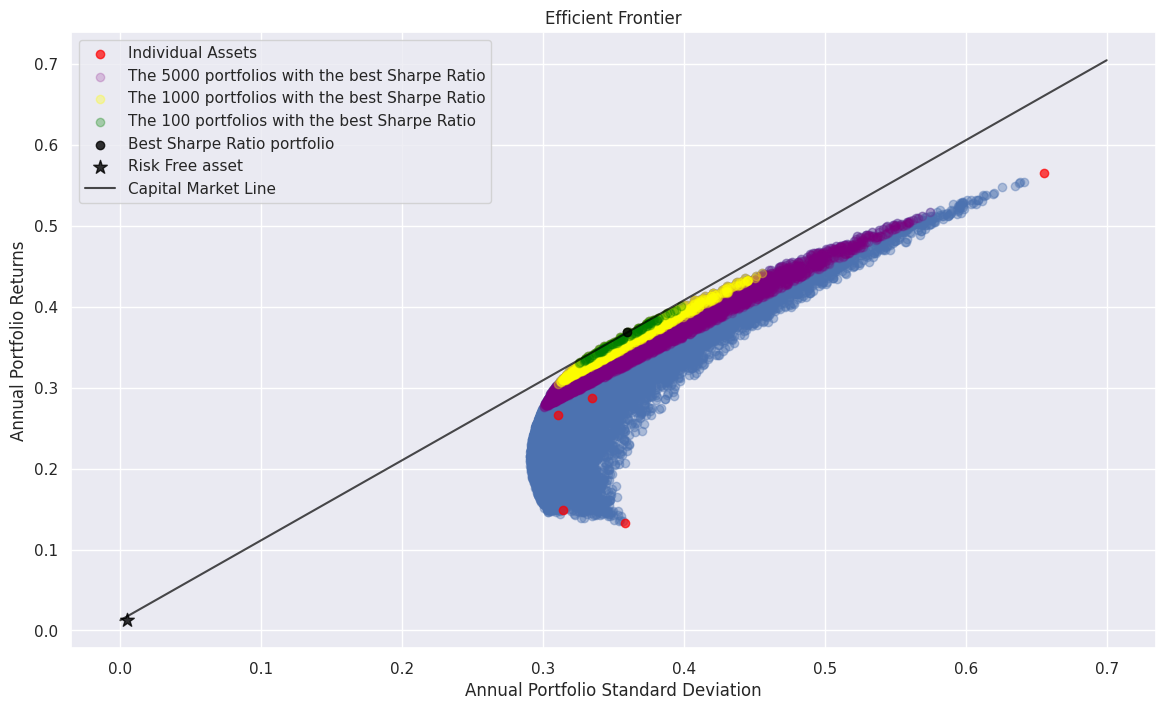

In [13]:
sigmas = np.linspace(0,0.7, 100)
CML = risk_free_rate + highest_sharpe_ratio['Sharpe Ratio'].iloc[0] * sigmas # This is the Capital Market Line

# Plot the portfolio returns vs portfolio variance
plt.figure(figsize = (14,8))
plt.scatter(x = eff_frontier_dataframe['Standard Deviation'], y = eff_frontier_dataframe['Returns'], alpha = 0.4)
plt.scatter(x = r.std() * np.sqrt(252), y = expected_returns, color = 'red', label = "Individual Assets", alpha = 0.7)
plt.scatter(x = highest_sharpe_ratio[:5000]['Standard Deviation'], y = highest_sharpe_ratio[:5000]['Returns'], color = 'purple', alpha = 0.2, label = "The 5000 portfolios with the best Sharpe Ratio" )
plt.scatter(x = highest_sharpe_ratio[:1000]['Standard Deviation'], y = highest_sharpe_ratio[:1000]['Returns'], color = 'yellow', alpha = 0.3, label = "The 1000 portfolios with the best Sharpe Ratio" )
plt.scatter(x = highest_sharpe_ratio[:100]['Standard Deviation'], y = highest_sharpe_ratio[:100]['Returns'], color = 'green', alpha = 0.3, label = "The 100 portfolios with the best Sharpe Ratio" )
plt.scatter(x = highest_sharpe_ratio.iloc[0,:]['Standard Deviation'], y = highest_sharpe_ratio.iloc[0,:]['Returns'], color = 'black', alpha = 0.8, label = "Best Sharpe Ratio portfolio" )
plt.scatter(x = (risk_free / 252).std(), y = risk_free_rate, color = 'black', alpha = 0.8, marker = '*', label = "Risk Free asset", s = 105)
plt.plot(sigmas, CML, color = 'black', label = "Capital Market Line", alpha = 0.7)


plt.title("Efficient Frontier")
plt.xlabel("Annual Portfolio Standard Deviation")
plt.ylabel("Annual Portfolio Returns")
plt.legend()
plt.show()

**6.1 Implementing Value at Risk (VaR) - Historical Method**

Calculating daily historical VaR can be done pretty simply in Python. The order of steps needed is as follows:

Calculate all daily returns.
Sort these returns from least to greatest.
Based on a given confidence level, return the corresponding percentile return. In other words, if we want to calculate daily VaR at a 95% confidence level and we are using 100 data points, the 5th smallest return of that sample would be considered our 95% VaR.

Let's visualize this first with a histogram using Bitcoin.

[*********************100%***********************]  1 of 1 completed


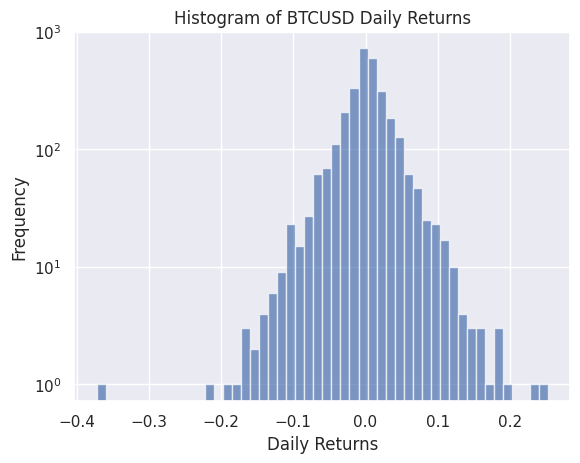

In [14]:
# Figure 1
btcusd = yf.download("BTC-USD", start="2014-09-18", end="2022-12-31", auto_adjust = False)['Adj Close']
btcusd_returns = btcusd.pct_change().dropna()

plt.hist(x = btcusd_returns, bins=50, log = True, alpha = 0.7)
plt.xlabel('Daily Returns')
plt.ylabel('Frequency')
plt.title('Histogram of BTCUSD Daily Returns')
plt.show()

In order to have a better visualization of the extreme events, we used a logarithmic scale for the  𝑦
  axis. Let's calculate the historical VaR from this data.

The next function getHistoricalVar() takes two arguments:

a series of daily returns
a confidence level, 95 for example, would correspond to 95% confidence

In [15]:
def getHistoricalVar(returns, confidenceLevel):
    var = np.quantile(returns, 1 - confidenceLevel)
    print(
        f"The Historical VaR with confidence {confidenceLevel} is {round(100 * var, 3)}% \n"
    )

getHistoricalVar(btcusd_returns, 0.90)
getHistoricalVar(btcusd_returns, 0.95)
getHistoricalVar(btcusd_returns, 0.99)

The Historical VaR with confidence 0.9 is -3.717% 

The Historical VaR with confidence 0.95 is -6.0% 

The Historical VaR with confidence 0.99 is -10.57% 



After running the function, we can see that the greater we make our confidence level, the lower the Value at Risk will be. This is a useful tool when determining how much a financial asset can lose over a certain time period.

You may be wondering now, since we only use a 95% confidence level, what happens on those 5% of days where losses exceed -6.02%. We can use another handy metric, Conditional Value at Risk (CVaR), to deal with these situations.

**6.2 Conditional Value at Risk (CVaR) using Historical Data**

Conditional Value at Risk (CVaR), also known as Expected Shortfall (ES), is a widely used risk measure in financial risk management. While Value at Risk (VaR) estimates the loss over a specific time horizon given a confidence level (e.g., 99%), CVaR goes beyond VaR by providing the expected loss if the VaR is exceeded. In other words, CVaR calculates the average loss in the tail of the distribution beyond the VaR threshold.

Mathematically, the CVaR at confidence level  𝛼
  is:

CVaR𝛼=𝔼[𝐿|𝐿>VaR𝛼]


where  𝐿
  represents the losses.

Historical CVaR is a non-parametric approach, which means that it does not rely on distribution assumptions for the returns. Instead, we can directly calculate the expectation of the losses after we have obtained the VaR. In practice, we can calculate the mean of the returns that are located to the left of the VaR.

In [16]:
# 6.2 Conditional Value at Risk (CVaR) using Historical Data

def getHistoricalCVar(returns, confidenceLevel):
    var = np.quantile(returns, 1 - confidenceLevel)
    cvar = returns[returns <= var].mean()
    print(
        f"With {confidenceLevel} percent confidence VaR, our Expected Shortfall is {round(100 * cvar, 3)} using historical VaR \n"
    )

getHistoricalCVar(btcusd_returns, 0.90)
getHistoricalCVar(btcusd_returns, 0.95)
getHistoricalCVar(btcusd_returns, 0.99)


With 0.9 percent confidence VaR, our Expected Shortfall is Ticker
BTC-USD   -6.893
dtype: float64 using historical VaR 

With 0.95 percent confidence VaR, our Expected Shortfall is Ticker
BTC-USD   -9.017
dtype: float64 using historical VaR 

With 0.99 percent confidence VaR, our Expected Shortfall is Ticker
BTC-USD   -14.285
dtype: float64 using historical VaR 



**7.2 Implementing Parametric VaR with Normal Distributio**

To calculate Value at Risk (VaR) using the parametric method, we will leverage the norm.ppf() function from Python’s scipy.stats module. The percent point function (ppf) is actually the inverse cumulative distribution function (CDF), and it allows us to compute the quantile that corresponds to a given confidence level.

In [17]:
mean = btcusd_returns.mean()
std = btcusd_returns.std()

var_90 = stats.norm.ppf(0.1, mean, std)[0]
var_95 = stats.norm.ppf(0.05, mean, std)[0]
var_99 = stats.norm.ppf(0.01, mean, std)[0]

print(f"The parametric VaR assuming a normal distribution with a 90% confidence interval, is {round(100 * var_90, 3)} \n")
print(f"The parametric VaR assuming a normal distribution with a 95% confidence interval, is {round(100 * var_95, 3)} \n")
print(f"The parametric VaR assuming a normal distribution with a 99% confidence interval, is {round(100 * var_99, 3)} \n")


The parametric VaR assuming a normal distribution with a 90% confidence interval, is -4.716 

The parametric VaR assuming a normal distribution with a 95% confidence interval, is -6.108 

The parametric VaR assuming a normal distribution with a 99% confidence interval, is -8.72 



Excess kurtosis observed in asset return distributions indicates that the normal distribution is not the best choice to represent the returns, especially in the tails.

Their fat-tailed nature indicates a higher probability of extreme outcomes, in many cases a lot higher than what a normal distribution predicts. The latter forces us to employ a heavy-tailed distribution like the Student's t-distribution.

**Exercise 6**

Calculate the Kurtosis of BTCUSD returns and make sure you understand the effects of high kurtosis on the tails. Then argue about the reason the normal distribution seems to underestimate the VaRs in comparison to the historical method.

In [19]:
# Step 1: Calculate Kurtosis

from scipy.stats import kurtosis

btcusd = yf.download("BTC-USD", start="2014-09-18", end="2022-12-31", auto_adjust=False)['Adj Close']
btcusd_returns = btcusd.pct_change().dropna()
btc_kurtosis = kurtosis(btcusd_returns, fisher=True)  # Fisher=True for excess kurtosis
print(f"Excess Kurtosis of BTCUSD Returns: {btc_kurtosis[0]:.3f}") # Access the single element

[*********************100%***********************]  1 of 1 completed

Excess Kurtosis of BTCUSD Returns: 7.173


**Expected Result:**

BTCUSD returns typically have high positive excess kurtosis (e.g., > 3), indicating fat tails.

**Effects of High Kurtosis:**

**Definition:**

Kurtosis measures the "tailedness" of a distribution. High kurtosis (leptokurtic) means more extreme values (fat tails) than a normal distribution.

**Impact on Tails:**

High kurtosis in BTCUSD returns indicates a higher probability of extreme gains or losses (e.g., large daily drops or spikes) compared to a normal distribution, which has thinner tails (kurtosis = 0 for excess kurtosis).

**Implication:**

Risk models assuming normality underestimate the likelihood and magnitude of extreme losses.

**Why Normal Distribution Underestimates VaR:**

**Historical Method:**

Uses actual return data, capturing fat tails and skewness directly from the empirical distribution. It reflects the true frequency of extreme losses.

**Normal Distribution (Parametric):**

 Assumes a bell-shaped curve with thin tails, underestimating the probability of extreme losses. For BTCUSD, which has fat tails (high kurtosis), the normal distribution predicts fewer and smaller extreme losses than observed historically.

**Example:**

If historical 95% VaR is -6.02% and parametric (normal) VaR is -4%, the normal method underestimates risk because it doesn’t account for the fat tails seen in BTCUSD’s historical data.

**Answer:**

BTCUSD returns have high kurtosis (e.g., > 3), indicating fat tails with more extreme losses than a normal distribution predicts.

The normal distribution underestimates VaR compared to the historical method because it assumes thinner tails, missing the higher probability and magnitude of extreme losses in the actual data.

**7.3 Implementing Parametric VaR with  𝑡-distribution**

The Student's t-distribution is commonly used as an alternative to the normal distribution when modeling data with fat tails. The degrees of freedom parameter controls the heaviness of the tails. As the degrees of freedom increase, the t-distribution approaches the normal distribution. For smaller degrees of freedom (dof), the tails become heavier, indicating a higher probability of extreme values.

In [20]:
# degrees of freedom

def getTVar(returns, dof, confidenceLevel):
    mean = returns.mean()
    std = returns.std()
    var = np.sqrt((dof - 2) / dof) * stats.t.ppf(1 - confidenceLevel, dof) * std + mean
    return (100 * var).round(3)

print(f"The parametric VaR using t-distribution with a confidence interval 0.9, is {getTVar(btcusd_returns, 5, 0.9)}% \n")
print(f"The parametric VaR using t-distribution with a confidence interval 0.95, is {getTVar(btcusd_returns, 5, 0.95)}% \n")
print(f"The parametric VaR using t-distribution with a confidence interval 0.99, is {getTVar(btcusd_returns, 5, 0.99)}% \n")

The parametric VaR using t-distribution with a confidence interval 0.9, is Ticker
BTC-USD   -4.186
dtype: float64% 

The parametric VaR using t-distribution with a confidence interval 0.95, is Ticker
BTC-USD   -5.786
dtype: float64% 

The parametric VaR using t-distribution with a confidence interval 0.99, is Ticker
BTC-USD   -9.793
dtype: float64% 



**8. VaR Using Monte Carlo Simulation**

The Monte Carlo VaR includes a series of simulations, where each return stream is represented as a random variable. This variable can be taken from any probability distribution, which is great because that means it doesn't necessarily assume a normal distribution. There is a lot of flexibility in choosing what kind of distribution to use. All the variables are then dollar-weighted and simulated to see what the total portfolio value is at the end of each run. These simulation returns are then sorted lowest to highest, and we can easily look to see what the Value at Risk is using similar computations to the historical method, except this time, we're using simulated returns instead of historical returns. For example, if you ran a series of 1,000 simulations, you would look at the 50th lowest value to determine the VaR for a 95% confidence interval.

Considerations for this method:

Estimations will not be effective if the probability distributions used to determine the random variables are incorrect. Many use past data to get an idea of what the probability distribution should be; this method allows for some subjectivity.

You can estimate VaR more effectively for portfolios containing options with this method versus the parametric method since Monte Carlo doesn't assume a normal distribution of returns.

Value at Risk (VaR) at 95.0% confidence level: -$3,253.02


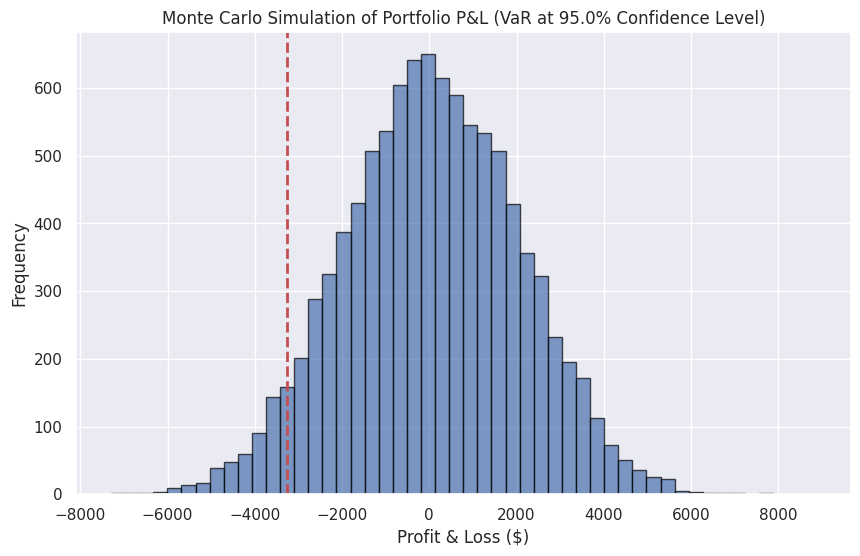

In [21]:
# Parameters
initial_investment = 100000  # Initial portfolio value (in dollars)
mean_return = 0.0005  # Daily mean return of the asset (e.g., 0.05%)
volatility = 0.02  # Daily volatility (not annual!) is 2%
days = 1  # 1 day time horizon
num_simulations = 10000  # Number of Monte Carlo simulations
confidence_level = 0.95  # Confidence level for VaR (e.g., 95%)

# Generate random returns based on normal distribution
np.random.seed(2024)  # For reproducibility
random_returns = np.random.normal(loc=mean_return * days, scale=volatility * np.sqrt(days), size=num_simulations)

# Calculate portfolio values at the end of the simulation
portfolio_end_values = initial_investment * (1 + random_returns)

# Calculate profit and loss (P&L)
portfolio_pnl = portfolio_end_values - initial_investment

# Calculate the VaR at the specified confidence level
VaR = np.percentile(portfolio_pnl, (1 - confidence_level) * 100)

# Output the results
print(f"Value at Risk (VaR) at {confidence_level * 100}% confidence level: -${abs(VaR):,.2f}")

#Plot the distribution of portfolio P&L
plt.figure(figsize=(10, 6))
plt.hist(portfolio_pnl, bins=50, edgecolor='black', alpha=0.7)
plt.axvline(x=VaR, color='r', linestyle='dashed', linewidth=2)
plt.title(f"Monte Carlo Simulation of Portfolio P&L (VaR at {confidence_level * 100}% Confidence Level)")
plt.xlabel('Profit & Loss ($)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

**9. Conclusion**

In this lesson, we've introduced a wide range of important concepts in financial risk analysis. We started by examining different types of returns, including total returns, dividend-adjusted returns, and excess returns, which form the foundation for more advanced risk metrics. We then explored the Sharpe Ratio and showcased how important this ratio is in the portfolio management context.

The later part of the lesson focused on downside risk metrics, particularly Value at Risk (VaR). We covered various methods for calculating VaR, including historical, parametric (with both normal and t-distributions), and Monte Carlo simulation approaches. We also introduced the concept of Conditional Value at Risk (CVaR) as an extension of VaR.